# Inference of Lambda for Context Steering

Here we demonstrate inference of the lambda parameter for Context Steering (CoS).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from cos.utils import load_hf_model_and_tokenizer
from cos.core import get_cos_logprob_hf
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/media/volume/yueru-s-data/miniconda3/envs/cos/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/media/volume/yueru-s-data/miniconda3/envs/cos/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
# Load in the model. You can also experiment with other chat models, such as T0pp and Mistral.
model, tokenizer = load_hf_model_and_tokenizer(model_name='llama-2-7b-chat', use_unsloth=False)

Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.48s/it]


## Personalization

#### Context inference

In [ ]:
from cos.core import infer_context_only_cos
# Example usage:
# prompts = [
#   [{"role": "user", "content": "Movie night with friends—recommend Bridesmaids or The Hangover? Please suggest one."}]
# ]
prompts=['“I’m ordering lunch. Choose one: ‘BBQ bacon burger’ or ‘falafel bowl’. Please answer with the item name only.”']
responses = ["BBQ bacon burger’"]
contexts  = ["I am vegetarian.", "I’m on a keto, high-protein diet.", "I have no dietary restrictions."]

result = infer_context_only_cos(
    model, tokenizer,
    prompts=prompts,
    contexts=contexts,
    responses=responses,
    lambda_value=1.0,
    base_mode="anchored",   # or "delta"
    base="off",
    temperature=0.8,
    is_chat=True,
    put_context_first=True,
    is_history=False,
    max_seq_len=1024,
    max_batch_size=4,
    show_progress=False
)
# Per-context totals for prompt 0
print("log-likelihood totals by context:", result["total_lp"][:, 0].tolist())
# If you want a share-like view across contexts for this prompt:
shares = torch.softmax(result["total_lp"][:, 0], dim=0)
print("shares across contexts:", shares.tolist())


log-likelihood totals by context: [-113.06914520263672, -108.38916015625, -126.18933868408203]
shares across contexts: [0.00919384229928255, 0.9908061623573303, 1.842762742398918e-08]


In [42]:
import torch

def debug_mask_and_span(tokenizer, get_tokens, prom_with, full_on, BATCH=4, device=None):
    """Show where the response starts, decode a slice, and report masked positions."""
    toks_prompt_on  = get_tokens(prom_with).to(device)
    toks_full_on    = get_tokens(full_on).to(device)

    p_on_mask  = toks_prompt_on.attention_mask
    m_on       = toks_full_on.attention_mask
    ids_on     = toks_full_on.input_ids

    prompt_len = p_on_mask.sum(dim=1)   # (N,)
    full_len   = m_on.sum(dim=1)        # (N,)

    for b in range(min(2, ids_on.size(0))):
        r0   = int(prompt_len[b])
        flen = int(full_len[b])
        print(f"[sample {b}] r0 (first response token index in FULL) = {r0}, full_len = {flen}")
        # decode around the start of response
        lo = max(r0-5, 0); hi = min(r0+15, ids_on.shape[1])
        print("... around r0:", tokenizer.decode(ids_on[b, lo:hi].tolist()))


In [45]:
from cos.utils import get_context_pair_dialogs
# Example: use the first context (vegetarian)
ctx = contexts[0]
prom_with, prom_off, full_on, full_off = get_context_pair_dialogs(
    prompts, [ctx]*len(prompts), put_context_first=True, is_history=False
)
debug_mask_and_span(tokenizer, tokenizer.apply_chat_template if True else tokenizer, prom_with, full_on,
                    device=next(model.parameters()).device)


ValueError: not enough values to unpack (expected 4, got 2)

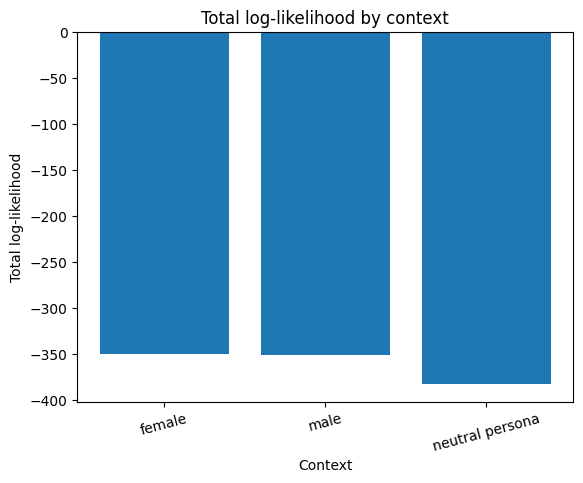

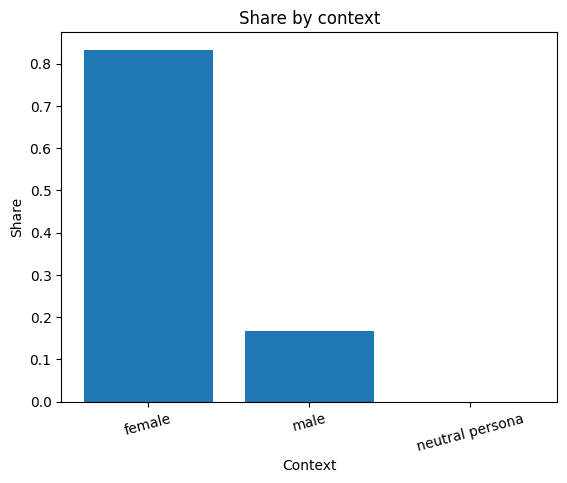

In [20]:
import numpy as np
import matplotlib.pyplot as plt
totals = result["total_lp"][:, 0].tolist()
contexts = ["female", "male", "neutral persona"]
shares=shares.cpu().numpy()
plt.figure()
plt.bar(contexts, totals)
plt.title("Total log-likelihood by context")
plt.xlabel("Context")
plt.ylabel("Total log-likelihood")
plt.xticks(rotation=15)
plt.show()

plt.figure()
plt.bar(contexts, shares)
plt.title("Share by context")
plt.xlabel("Context")
plt.ylabel("Share")
plt.xticks(rotation=15)
plt.show()

In [9]:
result

{'total_lp': tensor([[-267.2277],
         [-267.6295],
         [-297.1225]], device='cuda:0'),
 'prompts': ['Movie night with friends—recommend Bridesmaids or The Hangover? Please suggest one.'],
 'contexts': ['female', 'male', 'neutral persona'],
 'responses': ['Bridesmaids.'],
 'lambda': 1.0,
 'base_mode': 'anchored',
 'base': 'off',
 'base_total_lp': tensor([-205.5000], device='cuda:0', dtype=torch.float16)}

Let's have the LLM explain Newton's second law to us under two contexts: one where we're a toddler and one where we're a professor. We can also tune the level of influence (i.e. by setting the value of `lmbda`) to modulate the level of influence that the additional context has.

In [9]:
import json

# Load your JSON file (replace with your actual file path)
with open("/media/volume/yueru-s-data/context-steering/cos/female.json", "r") as f:
    data = json.load(f)

# Transform the list
converted = []
for item in data:
    role = "user" if item["speaker"] == "user1" else "assistant"
    converted.append({
        "role": role,
        "content": item["content"]
    })

# Save or print the result
with open("/media/volume/yueru-s-data/context-steering/cos/female_converted.json", "w") as f:
    json.dump(converted, f, indent=2)

# Optional: print preview
print(json.dumps(converted[:2], indent=2))  # show first 2 entries


[
  {
    "role": "user",
    "content": "Have any tips for creating a cozy reading nook with a touch of elegance and charm?"
  },
  {
    "role": "assistant",
    "content": "Creating a cozy reading nook with elegance and charm involves a blend of comfortable seating, good lighting, and tasteful decor. Here are some tips to help you craft the perfect space:\n\n1. **Choose the Right Location**: Find a quiet corner or window space in your home. Spaces with natural light are ideal, but a well-chosen area with artificial lighting works just as well.\n\n2. **Comfortable Seating**: Invest in a comfortable chair or chaise lounge. Consider a plush armchair or a classic wingback to combine comfort with elegance. Add soft, textured throws and a few decorative pillows.\n\n3. **Layered Lighting**: Incorporate multiple sources of light. A floor lamp or a table lamp with a soft, warm bulb can create a calming atmosphere. Consider a reading lamp with adjustable brightness for flexibility.\n\n4. **Bo

In [11]:
import json

# Load your JSON file (replace with your actual file path)
with open("/media/volume/yueru-s-data/context-steering/cos/male.json", "r") as f:
    data = json.load(f)

# Transform the list
converted = []
for item in data:
    role = "user" if item["speaker"] == "user1" else "assistant"
    converted.append({
        "role": role,
        "content": item["content"]
    })

# Save or print the result
with open("/media/volume/yueru-s-data/context-steering/cos/male_converted.json", "w") as f:
    json.dump(converted, f, indent=2)

# Optional: print preview
print(json.dumps(converted[:2], indent=2))  # show first 2 entries


[
  {
    "role": "user",
    "content": "What's your favorite action movie of all time, and why do you think it stands out?"
  },
  {
    "role": "assistant",
    "content": "As an AI, I don't have personal preferences or feelings, but I can share information about popular action movies that are highly regarded. \n\nOne action movie often cited as a favorite by many is \"Die Hard.\" Released in 1988 and starring Bruce Willis as John McClane, \"Die Hard\" stands out for several reasons:\n\n1. **Engaging Plot**: The film's plot, which takes place during a Christmas party at a high-rise building, combines elements of suspense and action expertly. McClane's struggle against heavily-armed terrorists makes for a compelling narrative.\n\n2. **Iconic Protagonist**: John McClane is a memorable character because he's relatable\u2014just a regular cop caught in an extraordinary situation. His wit, resourcefulness, and resilience make audiences root for him.\n\n3. **Well-Crafted Action Sequences*

In [61]:
with open("/media/volume/yueru-s-data/context-steering/cos/female_converted.json", "r") as f:
    female_contexts = json.load(f)

with open("/media/volume/yueru-s-data/context-steering/cos/male_converted.json", "r") as f:
    male_contexts = json.load(f)

In [ ]:
responses = [
    "meat gives me the protein boost I need for my workouts.",
    "I feel stronger and more satisfied after eating meat.",
    "I choose plants over meat for the planet.",
    "vegetables give me all the nutrients I need.",
    "a cruelty-free diet feels better for my conscience.",
]
prompts = ["I believe that"] * len(responses)
lambdas = np.arange(-3, 2, 0.1).tolist()
contexts = ["I am vegetarian.",] * len(responses)
contexts_neg = ["I am carnivore.",] * len(responses)
# contexts_history = [female_contexts[0:2]] * len(responses)
# contexts_history_neg = [male_contexts[0:2]] * len(responses)

In [26]:
responses = [
    "meat gives me the protein boost I need for my workouts.",
    "I feel stronger and more satisfied after eating meat.",
    "I choose plants over meat for the planet.",
    "vegetables give me all the nutrients I need.",
    "a cruelty-free diet feels better for my conscience.",
]
prompts = ["I believe that"] * len(responses)
lambdas = np.arange(-3, 2, 0.1).tolist()
contexts = ["I am male.",] * len(responses)
# contexts_neg = ["I am carnivore.",] * len(responses)
# contexts_history = [female_contexts[0:2]] * len(responses)
# contexts_history_neg = [male_contexts[0:2]] * len(responses)

In [39]:
results_all.head()

,responses,contexts,prompts,logprobs,lambdas,weight
0,meat gives me the protein boost I need for my ...,I am vegetarian.,I believe that,-324.630615,-3.0,1.437993e-64
1,meat gives me the protein boost I need for my ...,I am vegetarian.,I believe that,-311.204193,-2.9,2.707569e-61
2,meat gives me the protein boost I need for my ...,I am vegetarian.,I believe that,-297.853027,-2.8,6.158598e-58
3,meat gives me the protein boost I need for my ...,I am vegetarian.,I believe that,-284.606415,-2.7,1.708515e-54
4,meat gives me the protein boost I need for my ...,I am vegetarian.,I believe that,-271.509827,-2.6,5.524786e-51


ValueError: keyword ha is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid_capstyle

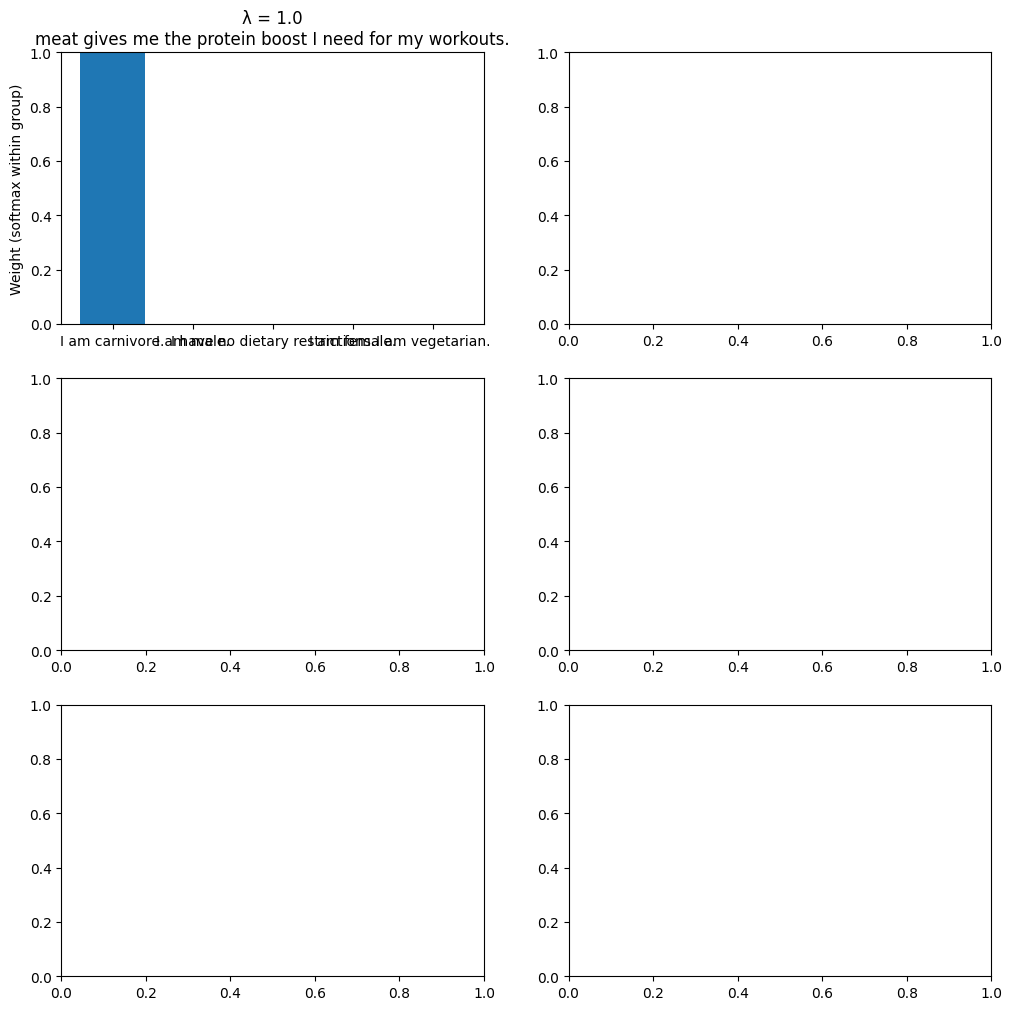

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Responses to plot
responses_filter = [
    "meat gives me the protein boost I need for my workouts.",
    "I feel stronger and more satisfied after eating meat.",
    "I choose plants over meat for the planet.",
    "vegetables give me all the nutrients I need.",
    "a cruelty-free diet feels better for my conscience.",
]

lambda_sel = 1.0
prompt_to_plot = results_all["prompts"].iloc[0]  # pick one prompt
context_col = "contexts" if "contexts" in results_all.columns else "context"

# Filter to λ=1.0, chosen prompt, and the selected responses
df = (
    results_all
      .copy()
      .query("prompts == @prompt_to_plot")
      .query("responses in @responses_filter")
)
# numeric compare to avoid float quirks
df = df[np.isclose(pd.to_numeric(df["lambdas"], errors="coerce"), lambda_sel)]

# Prepare subplots: one bar chart per response
n_resp = len(responses_filter)
ncols = 2
nrows = (n_resp + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows), squeeze=False)

for ax, resp in zip(axes.flat, responses_filter):
    d = df[df["responses"] == resp]
    if d.empty:
        ax.axis("off")
        continue

    # average weight per context (in case of duplicates)
    g = (
        d.groupby(context_col, as_index=False)["weight"]
         .mean()
         .sort_values("weight", ascending=False)
    )

    ax.bar(g[context_col], g["weight"])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Weight (softmax within group)")
    ax.set_title(f'λ = {lambda_sel}\n{resp}')
    ax.tick_params(axis="x", rotation=30, ha="right")

# Hide any unused axes
for j in range(len(responses_filter), nrows*ncols):
    axes.flat[j].axis("off")

fig.suptitle(f'Context weights at λ = {lambda_sel} (prompt = "{prompt_to_plot}")', y=1.02)
fig.tight_layout()
plt.show()


In [46]:
results_all['lambdas'].unique()

array([-3.00000000e+00, -2.90000000e+00, -2.80000000e+00, -2.70000000e+00,
       -2.60000000e+00, -2.50000000e+00, -2.40000000e+00, -2.30000000e+00,
       -2.20000000e+00, -2.10000000e+00, -2.00000000e+00, -1.90000000e+00,
       -1.80000000e+00, -1.70000000e+00, -1.60000000e+00, -1.50000000e+00,
       -1.40000000e+00, -1.30000000e+00, -1.20000000e+00, -1.10000000e+00,
       -1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01,  2.66453526e-15,  1.00000000e-01,
        2.00000000e-01,  3.00000000e-01,  4.00000000e-01,  5.00000000e-01,
        6.00000000e-01,  7.00000000e-01,  8.00000000e-01,  9.00000000e-01,
        1.00000000e+00,  1.10000000e+00,  1.20000000e+00,  1.30000000e+00,
        1.40000000e+00,  1.50000000e+00,  1.60000000e+00,  1.70000000e+00,
        1.80000000e+00,  1.90000000e+00])

In [62]:
filtered = results_all[
    (results_all['responses'] == "I choose plants over meat for the planet.") &
    (np.isclose(results_all['lambdas'], 1.0))
]

In [63]:
filtered

,responses,contexts,prompts,logprobs,lambdas,weight
140,I choose plants over meat for the planet.,I am vegetarian.,I believe that,-159.873611,1.0,4.663541e-24
140,I choose plants over meat for the planet.,I am carnivore.,I believe that,-106.151344,1.0,1.000000e+00
140,I choose plants over meat for the planet.,I have no dietary restrictions.,I believe that,-159.948318,1.0,4.327838e-24
140,I choose plants over meat for the planet.,I am female.,I believe that,-149.655548,1.0,1.277510e-19
140,I choose plants over meat for the planet.,I am male.,I believe that,-155.402588,1.0,4.078089e-22


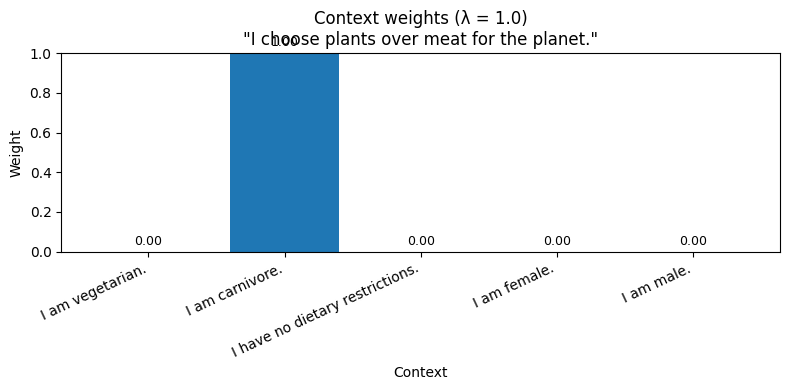

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# pick the row set you showed
resp_sel   = "I choose plants over meat for the planet."
lambda_sel = 1.0

df_plot = results_all[
    (results_all["responses"] == resp_sel) &
    (results_all["lambdas"]  == lambda_sel)
][["contexts","weight"]]

# (optional) average duplicates and sort by weight
df_plot = (df_plot.groupby("contexts", as_index=False)
                  .mean()
                  .sort_values("weight", ascending=False))

df_plot=filtered.copy()

plt.figure(figsize=(8,4))
bars = plt.bar(df_plot["contexts"], df_plot["weight"])
plt.xlabel("Context")
plt.ylabel("Weight")
plt.ylim(0, 1)
plt.title(f'Context weights (λ = {lambda_sel})\n"{resp_sel}"')
plt.xticks(rotation=25, ha="right")

# annotate bars
for b, v in zip(bars, df_plot["weight"].to_numpy()):
    plt.text(b.get_x()+b.get_width()/2, v + 0.02, f"{v:.2f}",
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


In [27]:
from cos.core import get_cos_logprob_hf

assert tokenizer.padding_side == 'left'
outs = get_cos_logprob_hf(
    model, 
    tokenizer,
    prompts=prompts,
    contexts=contexts,
    contexts_neg = None,
    responses=responses,
    lambdas=lambdas, 
    is_chat=False,
    put_context_first=True, 
    max_gen_len=None,
    temperature=0.3,
    show_progress=False,
    verbose=True,
)
assert len(outs["total_logprobs"]) == len(prompts) * len(lambdas)
total_logprobs = outs["total_logprobs"].reshape(len(prompts), len(lambdas))


results = pd.DataFrame({
    "responses": [r for r in responses for i in range(len(lambdas))],
    "contexts": [c for c in contexts for i in range(len(lambdas))],
    # "contexts_neg": [c for c in contexts_neg for i in range(len(lambdas))] if contexts_neg is not None else [],
    "prompts": [p for p in prompts for i in range(len(lambdas))],
    "logprobs": total_logprobs.flatten().tolist(),
    "lambdas": lambdas * len(responses)
})

prompts: ['I am male. I believe that', 'I am male. I believe that', 'I am male. I believe that', 'I am male. I believe that', 'I am male. I believe that']
prompts_full: ['I am male. I believe that meat gives me the protein boost I need for my workouts.', 'I am male. I believe that I feel stronger and more satisfied after eating meat.', 'I am male. I believe that I choose plants over meat for the planet.', 'I am male. I believe that vegetables give me all the nutrients I need.', 'I am male. I believe that a cruelty-free diet feels better for my conscience.']
next_lp: torch.Size([8, 21, 32000])
next_lp_nc: torch.Size([8, 21, 32000])
lambdas: tensor([-3.0000, -2.9000, -2.8000, -2.7000, -2.6000, -2.5000, -2.4000, -2.3000],
       device='cuda:0')
cos_lp: torch.Size([8, 21, 32000])
if_return_probs: False
next_lp: torch.Size([8, 21, 32000])
next_lp_nc: torch.Size([8, 21, 32000])
lambdas: tensor([-2.2000, -2.1000, -2.0000, -1.9000, -1.8000, -1.7000, -1.6000, -1.5000],
       device='cuda:0')


In [28]:
results.head()

,responses,contexts,prompts,logprobs,lambdas
0,meat gives me the protein boost I need for my ...,I am male.,I believe that,-230.802979,-3.0
1,meat gives me the protein boost I need for my ...,I am male.,I believe that,-220.281113,-2.9
2,meat gives me the protein boost I need for my ...,I am male.,I believe that,-210.053162,-2.8
3,meat gives me the protein boost I need for my ...,I am male.,I believe that,-200.159149,-2.7
4,meat gives me the protein boost I need for my ...,I am male.,I believe that,-190.664001,-2.6


In [29]:
results_all=pd.concat([results_all,results])

In [30]:
results_all.shape

(1250, 5)

In [ ]:
import numpy as np

def softmax_1d(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.max(x)                 # stability shift
    exps = np.exp(x - m)
    return exps / exps.sum()

keys = ["responses", "prompts", "lambdas"]

# softmax over 'logprobs' within each group
results_all["weight"] = (
    results_all.groupby(keys)["logprobs"]
               .transform(lambda v: softmax_1d(v.values))
)

In [ ]:
checks = results_all.groupby(keys)["weight"].sum()
print(checks.head())

responses                                  prompts         lambdas
I choose plants over meat for the planet.  I believe that  -3.0       1.0
                                                           -2.9       1.0
                                                           -2.8       1.0
                                                           -2.7       1.0
                                                           -2.6       1.0
Name: weight, dtype: float64


In [22]:
logits=torch.tensor([[0.8, 0.6, 0.5],[0.9, 0.8, 0.2],[1.0, 1.0, 0.1]])
logits = logits.softmax(dim=-1)

In [25]:
import torch

# 偏移向量
f = torch.tensor([0.1, 0.3, -0.1])

# 基础分布
base = torch.tensor([0.8, 0.1, 0.1])

# 构造一系列 logits：base, base+f, base+2f, ...
logits = torch.stack([base + k * f for k in range(5)])

# 对最后一个维度做 softmax
probs = torch.softmax(logits, dim=-1)

print(probs)


tensor([[0.5017, 0.2491, 0.2491],
        [0.4967, 0.3013, 0.2020],
        [0.4822, 0.3572, 0.1605],
        [0.4593, 0.4156, 0.1252],
        [0.4295, 0.4747, 0.0958]])


In [23]:
logits

tensor([[0.3907, 0.3199, 0.2894],
        [0.4164, 0.3768, 0.2068],
        [0.4155, 0.4155, 0.1689]])

In [15]:
results

,responses,contexts,contexts_neg,prompts,logprobs,lambdas
0,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-300.869385,-3.0
1,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-287.015106,-2.9
2,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-273.342194,-2.8
3,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-260.032043,-2.7
4,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-247.267075,-2.6
...,...,...,...,...,...,...
245,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-177.294113,1.5
246,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-181.218109,1.6
247,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-185.234085,1.7
248,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-189.696548,1.8


In [17]:
test

,responses,contexts,contexts_neg,prompts,logprobs,lambdas
0,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-300.869385,-3.000000e+00
1,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-287.015106,-2.900000e+00
2,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-273.342194,-2.800000e+00
3,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-260.032043,-2.700000e+00
4,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-247.267075,-2.600000e+00
5,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-235.091934,-2.500000e+00
6,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-223.441345,-2.400000e+00
7,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-212.231445,-2.300000e+00
8,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-201.403259,-2.200000e+00
9,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-190.937485,-2.100000e+00


slope = -23.767835
intercept = -214.552638
R^2 = 0.131144
p-value = 0.00976
std_err = 8.830159


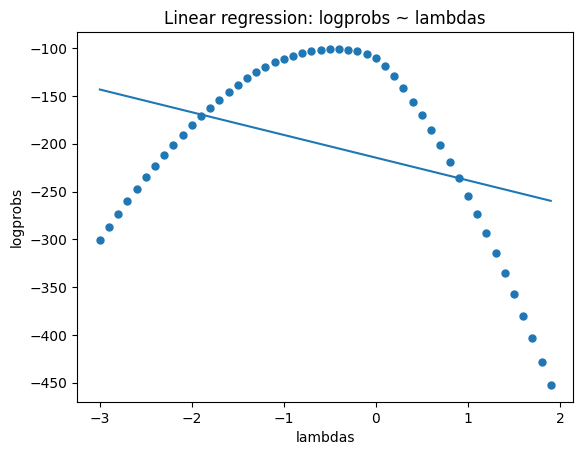

In [16]:
import pandas as pd
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
test=results[results["responses"] == "meat gives me the protein boost I need for my workouts."]

x = test["lambdas"].values
y = test["logprobs"].values

res = linregress(x, y)
print(f"slope = {res.slope:.6f}")
print(f"intercept = {res.intercept:.6f}")
print(f"R^2 = {res.rvalue**2:.6f}")
print(f"p-value = {res.pvalue:.3g}")
print(f"std_err = {res.stderr:.6f}")

# Optional: plot with fitted line
xx = np.linspace(x.min(), x.max(), 200)
yy = res.slope * xx + res.intercept
plt.scatter(x, y, s=25)
plt.plot(xx, yy)
plt.xlabel("lambdas")
plt.ylabel("logprobs")
plt.title("Linear regression: logprobs ~ lambdas")
plt.show()

In [11]:
results

,responses,contexts,contexts_neg,prompts,logprobs,lambdas
0,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-111.812851,-3.0
1,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-111.769913,-2.9
2,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-111.726959,-2.8
3,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-111.684013,-2.7
4,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-111.641068,-2.6
...,...,...,...,...,...,...
245,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-130.556320,1.5
246,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-130.475983,1.6
247,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-130.395645,1.7
248,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-130.581085,1.8


slope = 0.419428
intercept = -110.538674
R^2 = 0.995617
p-value = 2.9e-58
std_err = 0.004017


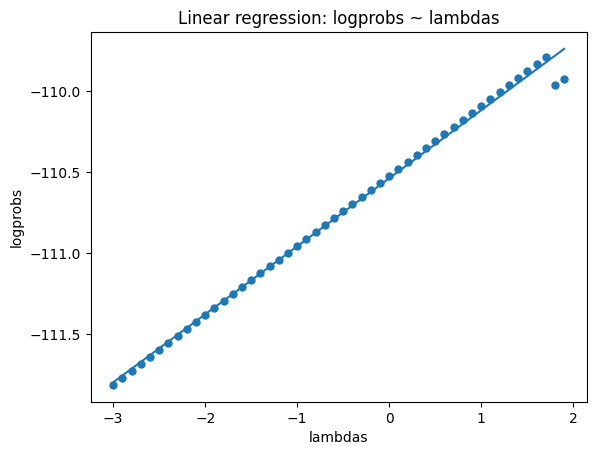

In [13]:
import pandas as pd
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
test=results[results["responses"] == "meat gives me the protein boost I need for my workouts."]

x = test["lambdas"].values
y = test["logprobs"].values

res = linregress(x, y)
print(f"slope = {res.slope:.6f}")
print(f"intercept = {res.intercept:.6f}")
print(f"R^2 = {res.rvalue**2:.6f}")
print(f"p-value = {res.pvalue:.3g}")
print(f"std_err = {res.stderr:.6f}")

# Optional: plot with fitted line
xx = np.linspace(x.min(), x.max(), 200)
yy = res.slope * xx + res.intercept
plt.scatter(x, y, s=25)
plt.plot(xx, yy)
plt.xlabel("lambdas")
plt.ylabel("logprobs")
plt.title("Linear regression: logprobs ~ lambdas")
plt.show()

In [9]:
results

,responses,contexts,contexts_neg,prompts,logprobs,lambdas
0,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-300.663696,-3.0
1,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-286.821106,-2.9
2,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-273.164185,-2.8
3,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-259.875366,-2.7
4,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-247.129547,-2.6
...,...,...,...,...,...,...
245,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-177.342682,1.5
246,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-181.268829,1.6
247,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-185.285248,1.7
248,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-189.712921,1.8


#### Context_history

In [127]:
responses = [
    "Bridesmaids.",
    "Hangover."
]
prompts = ["Movie night with my friends is coming up—which movie would you recommend for a fun time? The Bridesmaids or The Hangover? Please just suggest one"] * len(responses)
lambdas = np.arange(-3, 2, 0.1).tolist()
# contexts = ["I am vegetarian.",] * len(responses)
# contexts_neg = ["I am carnivore.",] * len(responses)
contexts_history = [female_contexts[0:2]] * len(responses)
contexts_history_neg = [male_contexts[0:2]] * len(responses)

In [120]:
len(prompts),len(contexts_history), len(contexts_history_neg), len(responses), len(lambdas)

(2, 2, 2, 2, 50)

In [128]:
contexts_history

[[{'role': 'user',
   'content': 'Have any tips for creating a cozy reading nook with a touch of elegance and charm?'},
  {'role': 'assistant',
   'content': "Creating a cozy reading nook with elegance and charm involves a blend of comfortable seating, good lighting, and tasteful decor. Here are some tips to help you craft the perfect space:\n\n1. **Choose the Right Location**: Find a quiet corner or window space in your home. Spaces with natural light are ideal, but a well-chosen area with artificial lighting works just as well.\n\n2. **Comfortable Seating**: Invest in a comfortable chair or chaise lounge. Consider a plush armchair or a classic wingback to combine comfort with elegance. Add soft, textured throws and a few decorative pillows.\n\n3. **Layered Lighting**: Incorporate multiple sources of light. A floor lamp or a table lamp with a soft, warm bulb can create a calming atmosphere. Consider a reading lamp with adjustable brightness for flexibility.\n\n4. **Bookshelves and Sto

In [ ]:
assert tokenizer.padding_side == 'left'
outs = get_cos_logprob_hf(
    model, 
    tokenizer,
    prompts=prompts,
    contexts=contexts_history,
    contexts_neg=contexts_history_neg,
    responses=responses,
    lambdas=lambdas, 
    is_chat=True,
    put_context_first=True, 
    max_gen_len=None,
    temperature=0.3,
    show_progress=False,
    verbose=True,
    is_history=True,  # Set to True to use history contexts
)
assert len(outs["total_logprobs"]) == len(prompts) * len(lambdas)
total_logprobs = outs["total_logprobs"].reshape(len(prompts), len(lambdas))


results = pd.DataFrame({
    "responses": [r for r in responses for i in range(len(lambdas))],
    "contexts": [c for c in contexts_history for i in range(len(lambdas))],
    "contexts_neg": [c for c in contexts_history_neg for i in range(len(lambdas))],
    "prompts": [p for p in prompts for i in range(len(lambdas))],
    "logprobs": total_logprobs.flatten().tolist(),
    "lambdas": lambdas * len(responses)
})

NameError: name 'contexts_history' is not defined

In [130]:
results

,responses,contexts,contexts_neg,prompts,logprobs,lambdas
0,Bridesmaids.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-76.428726,-3.0
1,Bridesmaids.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-77.621155,-2.9
2,Bridesmaids.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-78.825516,-2.8
3,Bridesmaids.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-80.042442,-2.7
4,Bridesmaids.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-81.272942,-2.6
...,...,...,...,...,...,...
95,Hangover.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-203.039078,1.5
96,Hangover.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-205.782379,1.6
97,Hangover.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-208.569534,1.7
98,Hangover.,"[{'role': 'user', 'content': 'Have any tips fo...","[{'role': 'user', 'content': 'What's your favo...",Movie night with my friends is coming up—which...,-211.440384,1.8


In [124]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid_spec


def plot(
    responses=responses,
    contexts=['female'],
    contexts_neg=['male'],
    prompts=prompts,
    lambdas=lambdas,
):
    import matplotlib.pyplot as plt
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(0, len(responses) - 1)
    fig = plt.figure(figsize=(20, 10))
    gs = grid_spec.GridSpec(len(responses),1)
    colors = ['#0000ff', '#3300cc', '#660099', '#990066', '#cc0033', '#ff0000']
    ax_objs = []
    y_max = 0.6
    xlims = (-3, 2)

    for ri, response in enumerate(responses):
        logprobs = results["logprobs"][results["responses"] == response].tolist()
        lambdas = results["lambdas"][results["responses"] == response].tolist()

        probs = F.softmax(torch.tensor(logprobs))
        ax_objs.append(fig.add_subplot(gs[ri:ri+1, 0:]))
        ax_objs[-1].plot(lambdas, probs, label=response,color="#f0f0f0",lw=1)
        # ax_objs[-1].fill_between(lambdas, probs, alpha=1,color=colors[ri])
        ax_objs[-1].fill_between(lambdas, probs, alpha=0.8,color=cmap(norm(ri)))
        ax_objs[-1].set_ylim(0,y_max)
        ax_objs[-1].set_xlim(*xlims)
        spines = ["top","right","left","bottom"]
        for s in spines:
            ax_objs[-1].spines[s].set_visible(False)
        ax_objs[-1].set_yticklabels([])
        ax_objs[-1].set_xticks([])
        ax_objs[-1].set_xticklabels([])
        ax_objs[-1].set_yticks([])
        rect = ax_objs[-1].patch
        rect.set_alpha(0)
        if len(response) > 30:
            rs = response.split(" ")
            response = " ".join(rs[:len(rs)//2]) + "\n" + " ".join(rs[len(rs)//2:])
        ax_objs[-1].text(xlims[1],0, response, fontsize=20,ha="right", wrap=True, style="italic")

    ax_objs[0].text(xlims[1],y_max/4, prompts[0] + "...",fontsize=15,ha="right", wrap=True)
    ax_objs[0].text(xlims[0],y_max/2, contexts_neg[0],fontsize=20,ha="left", wrap=True)

    ax_objs[0].text(xlims[1],y_max/2, contexts[0],fontsize=20,ha="right", wrap=True)
    gs.update(hspace=-0.8)
    plt.tight_layout()
    plt.show()


In [133]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid_spec

def plot(
    responses=responses,
    contexts=['female'],
    contexts_neg=['male'],
    prompts=prompts,
    lambdas=lambdas,
):
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(0, len(responses) - 1)
    fig = plt.figure(figsize=(20, 10))
    gs = grid_spec.GridSpec(len(responses), 1)
    ax_objs = []
    y_max = 0.6
    xlims = (-3, 2)

    for ri, response in enumerate(responses):
        logprobs_raw = results["logprobs"][results["responses"] == response].tolist()
        lambdas_raw = results["lambdas"][results["responses"] == response].tolist()

        # Filter out -inf entries
        filtered = [(lp, lb) for lp, lb in zip(logprobs_raw, lambdas_raw) if lp != float("-inf")]
        if not filtered:
            continue  # skip if all values were -inf

        logprobs, lambdas_filtered = zip(*filtered)
        logprobs_tensor = torch.tensor(logprobs, dtype=torch.float32)
        probs = F.softmax(logprobs_tensor, dim=0)

        ax = fig.add_subplot(gs[ri:ri + 1, 0:])
        ax.plot(lambdas_filtered, probs, label=response, color="#f0f0f0", lw=1)
        ax.fill_between(lambdas_filtered, probs, alpha=0.8, color=cmap(norm(ri)))
        ax.set_ylim(0, y_max)
        ax.set_xlim(*xlims)
        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(False)
        ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_yticks([])
        ax.patch.set_alpha(0)
        if len(response) > 30:
            rs = response.split(" ")
            response = " ".join(rs[:len(rs) // 2]) + "\n" + " ".join(rs[len(rs) // 2:])
        ax.text(xlims[1], 0, response, fontsize=20, ha="right", wrap=True, style="italic")
        ax_objs.append(ax)

    if ax_objs:
        ax_objs[0].text(xlims[1], y_max / 4, prompts[0] + "...", fontsize=15, ha="right", wrap=True)
        ax_objs[0].text(xlims[0], y_max / 2, contexts_neg[0], fontsize=20, ha="left", wrap=True)
        ax_objs[0].text(xlims[1], y_max / 2, contexts[0], fontsize=20, ha="right", wrap=True)

    gs.update(hspace=-0.8)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_7436/3514259076.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


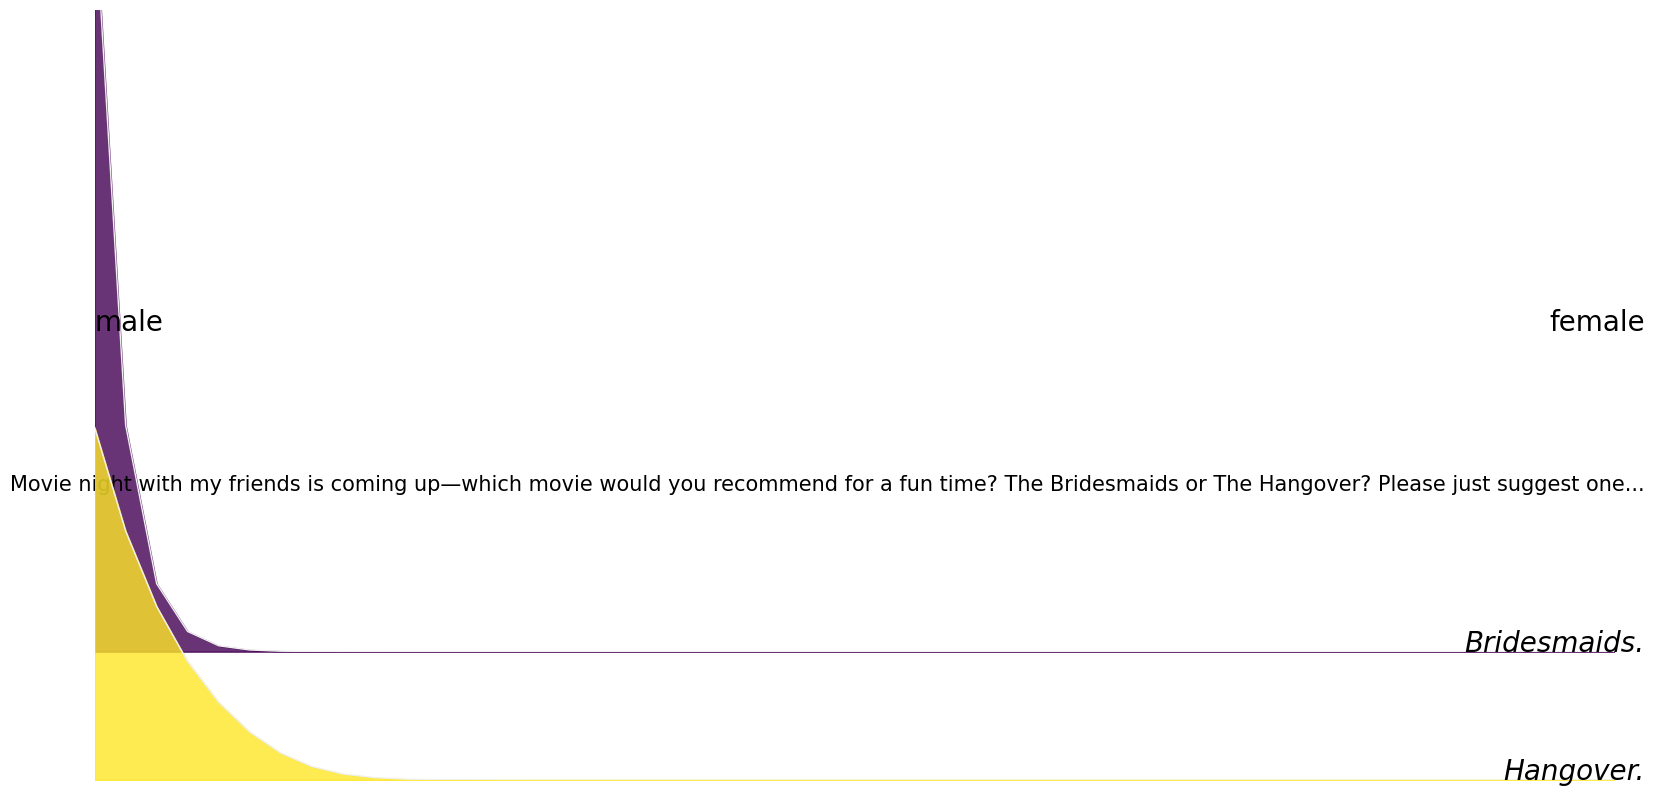

In [134]:
plot()

In [8]:
results

,responses,contexts,contexts_neg,prompts,logprobs,lambdas
0,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-300.375488,-3.0
1,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-286.547058,-2.9
2,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-272.905182,-2.8
3,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-259.632385,-2.7
4,meat gives me the protein boost I need for my ...,I am vegetarian.,I am carnivore.,I believe that,-246.904251,-2.6
...,...,...,...,...,...,...
245,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-177.271133,1.5
246,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-181.194489,1.6
247,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-185.207367,1.7
248,a cruelty-free diet feels better for my consci...,I am vegetarian.,I am carnivore.,I believe that,-189.888550,1.8


Here, we see that under the baseline `lmbda=-1.0`, the model generates pretty similar responses for each context. For increased values of `lmbda`, we get more personalized responses.

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid_spec


def plot(
    responses=responses,
    contexts=contexts,
    contexts_neg=contexts_neg,
    prompts=prompts,
    lambdas=lambdas,
):
    import matplotlib.pyplot as plt
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(0, len(responses) - 1)
    fig = plt.figure(figsize=(20, 10))
    gs = grid_spec.GridSpec(len(responses),1)
    colors = ['#0000ff', '#3300cc', '#660099', '#990066', '#cc0033', '#ff0000']
    ax_objs = []
    y_max = 0.6
    xlims = (-2, 2)

    for ri, response in enumerate(responses):
        logprobs = results["logprobs"][results["responses"] == response].tolist()
        lambdas = results["lambdas"][results["responses"] == response].tolist()

        probs = F.softmax(torch.tensor(logprobs))
        ax_objs.append(fig.add_subplot(gs[ri:ri+1, 0:]))
        ax_objs[-1].plot(lambdas, probs, label=response,color="#f0f0f0",lw=1)
        # ax_objs[-1].fill_between(lambdas, probs, alpha=1,color=colors[ri])
        ax_objs[-1].fill_between(lambdas, probs, alpha=0.8,color=cmap(norm(ri)))
        ax_objs[-1].set_ylim(0,y_max)
        ax_objs[-1].set_xlim(*xlims)
        spines = ["top","right","left","bottom"]
        for s in spines:
            ax_objs[-1].spines[s].set_visible(False)
        ax_objs[-1].set_yticklabels([])
        ax_objs[-1].set_xticks([])
        ax_objs[-1].set_xticklabels([])
        ax_objs[-1].set_yticks([])
        rect = ax_objs[-1].patch
        rect.set_alpha(0)
        if len(response) > 30:
            rs = response.split(" ")
            response = " ".join(rs[:len(rs)//2]) + "\n" + " ".join(rs[len(rs)//2:])
        ax_objs[-1].text(xlims[1],0, response, fontsize=20,ha="right", wrap=True, style="italic")

    ax_objs[0].text(xlims[1],y_max/4, prompts[0] + "...",fontsize=30,ha="right", wrap=True)
    ax_objs[0].text(xlims[0],y_max/2, contexts_neg[0],fontsize=30,ha="left", wrap=True)

    ax_objs[0].text(xlims[1],y_max/2, contexts[0],fontsize=30,ha="right", wrap=True)
    gs.update(hspace=-0.8)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.tensor(logprobs))
/tmp/ipykernel_7436/2343244271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(torch.ten

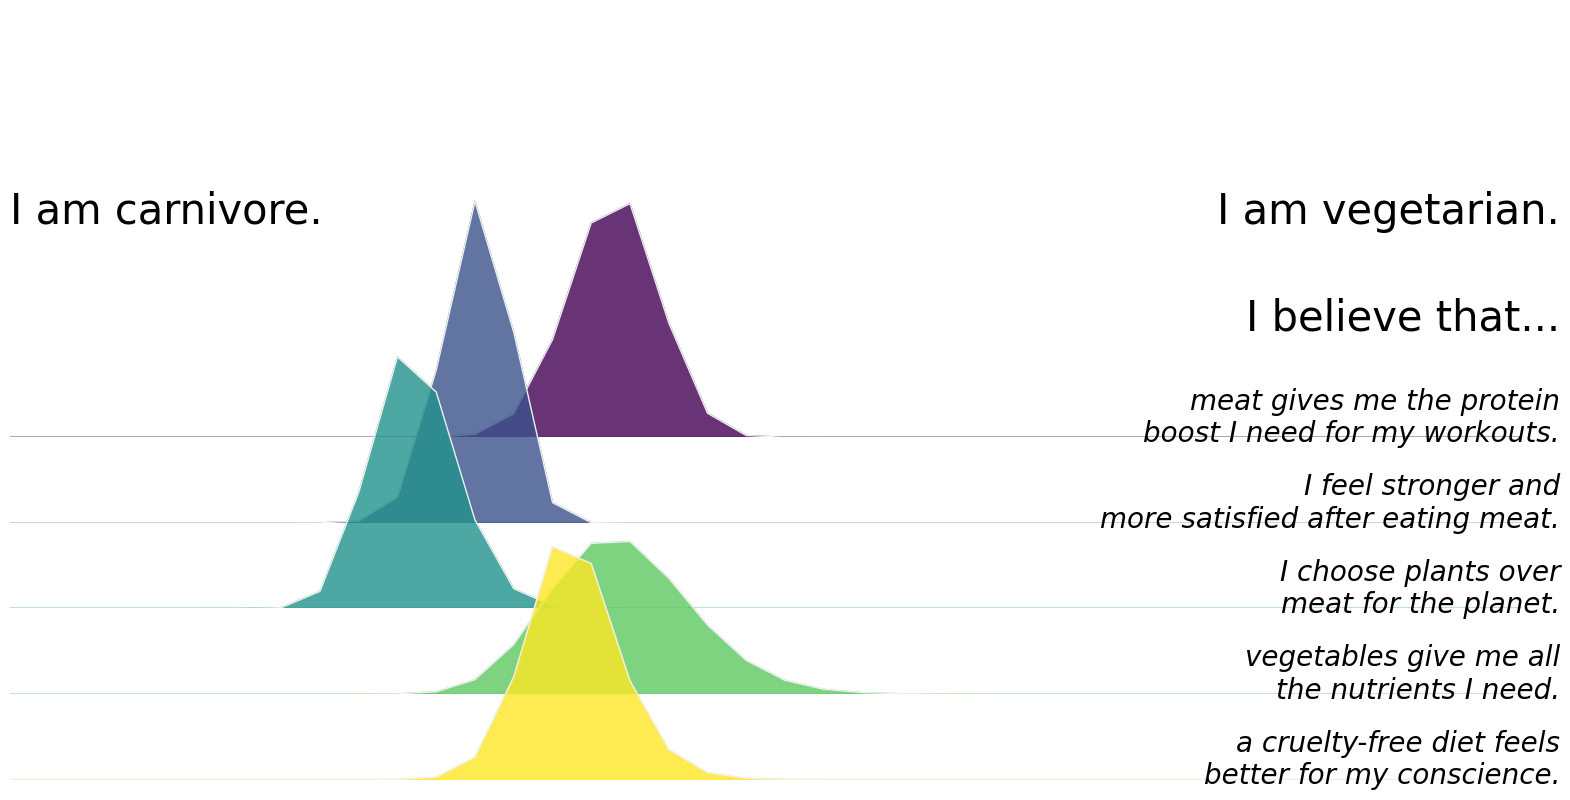

In [7]:
plot()